In [72]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

In [73]:
df = pd.read_csv('../amz_uk_price_prediction_dataset.csv')

art 1: Understanding Product Categories
Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

Frequency Tables:

Generate a frequency table for the product category.
Which are the top 5 most listed product categories?
Visualizations:

Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [74]:
freq_table = df.category.value_counts()

In [75]:
top5_cat = df.category.value_counts()[:5]
top5_cat.index

Index(['Sports & Outdoors', 'Beauty', 'Handmade Clothing, Shoes & Accessories',
       'Bath & Body', 'Birthday Gifts'],
      dtype='object', name='category')

<Axes: xlabel='category', ylabel='count'>

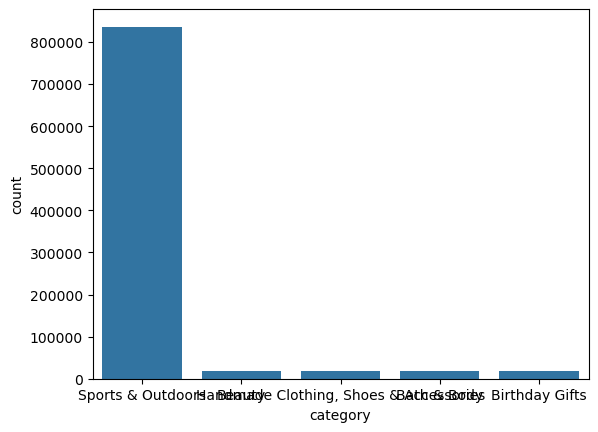

In [76]:
sns.barplot(freq_table[:5])

([<matplotlib.patches.Wedge at 0x15961f81810>,
 [Text(-1.061989487463534, 0.2866676272566199, ''),
  Text(0.9852467003838558, -0.48917168702074837, ''),
  Text(1.0412847474771803, -0.3545787284530543, ''),
  Text(1.0788688426253243, -0.21457404412531686, ''),
  Text(1.0976548098889691, -0.07179079556329825, '')])

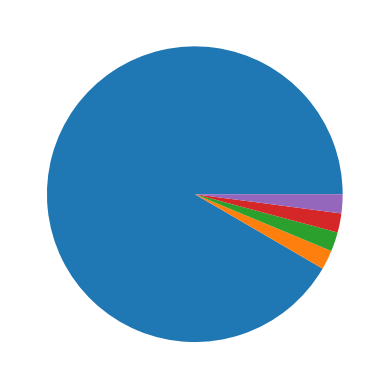

In [77]:
plt.pie(top5_cat)

In [78]:
#Insight: Sports & Outdoors dominate the listings

Part 2: Delving into Product Pricing
Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

Measures of Centrality:

Calculate the mean, median, and mode for the price of products.
What's the average price point of products listed? How does this compare with the most common price point (mode)?
Measures of Dispersion:

Determine the variance, standard deviation, range, and interquartile range for product price.
How varied are the product prices? Are there any indicators of a significant spread in prices?
Visualizations:

Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..
Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.


In [79]:
df.price.describe()

price_mean = df.price.mean()
price_median = df.price.median()
price_mode = df.price.mode()
average_price_point=price_mean
display(f'average price is {average_price_point}')
for i in price_mode:
    price_diff_mean_mode = price_mean-i
    display(f'difference between average and mode is {price_diff_mean_mode}')

#Insight: The difference between the average price and the mode is huge, the average price is much bigger due to the presence of extremely
#large outliers

price_variance = df.price.var()
price_standard_deviation = df.price.std()
price_range = np.ptp(df.price)
display(f'variance is {price_variance}')
display(f'standard deviation is {price_standard_deviation}')
display(f'range is {price_range}')

#Insight: In line with findings above, there is a very large variance, as well as standard deviation and range

Q3_price = np.quantile(df['price'], 0.75)
Q1_price = np.quantile(df['price'], 0.25)
IQR_price = Q3_price - Q1_price

variation_price = df.price.std()

'average price is 89.24380943923661'

'difference between average and mode is 79.25380943923662'

'variance is 119445.48532256528'

'standard deviation is 345.60886175352226'

'range is 100000.0'

(array([2.443482e+06, 1.560000e+02, 1.100000e+01, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 1.000000e+00,
        0.000000e+00, 1.000000e+00]),
 array([     0.,  10000.,  20000.,  30000.,  40000.,  50000.,  60000.,
         70000.,  80000.,  90000., 100000.]),
 <BarContainer object of 10 artists>)

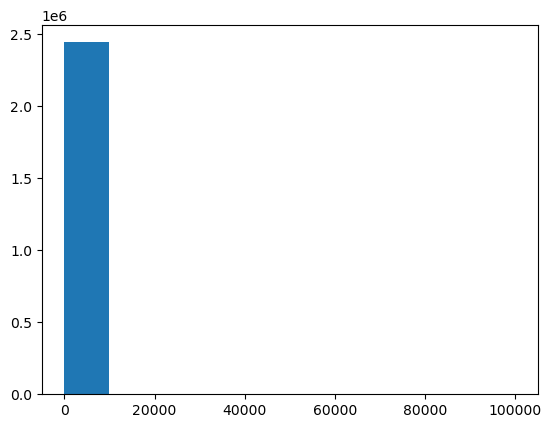

In [80]:
#sns.histplot(df.price)
# sns.histplot(df[df.price>10000].price)
plt.hist(df.price)

(array([257986., 244551., 167528., 125618., 104346.,  91218.,  76598.,
         45947.,  50114.,  38776.]),
 array([10.   , 13.598, 17.196, 20.794, 24.392, 27.99 , 31.588, 35.186,
        38.784, 42.382, 45.98 ]),
 <BarContainer object of 10 artists>)

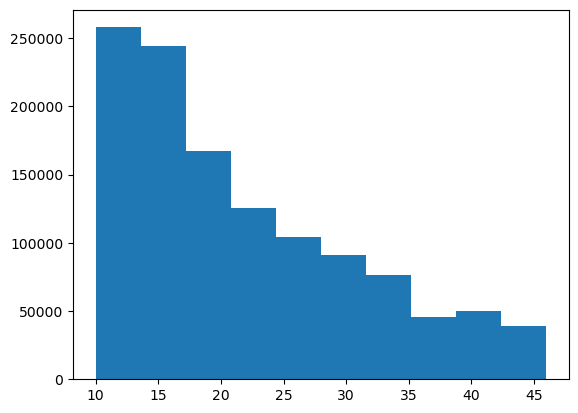

In [81]:
#we can look at how the median values are distributed to get a sense of the data
plt.hist(df[(df.price>Q1_price) & (df.price <Q3_price)].price)

In [82]:
#Insight: Most of the values fall below 10000 gbp

<Axes: ylabel='price'>

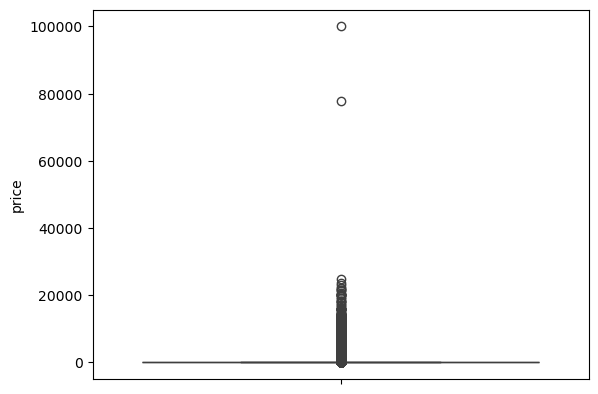

In [83]:
sns.boxplot(df.price)

In [84]:
# Insight: from looking at the boxplot it's clear that there are a very large number of 
#outliers that fall above the 75 percentile, as indicated by the whiskers

Part 3: Unpacking Product Ratings
Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

Measures of Centrality:

Calculate the mean, median, and mode for the rating of products.
How do customers generally rate products? Is there a common trend?
Measures of Dispersion:

Determine the variance, standard deviation, and interquartile range for product rating.
Are the ratings consistent, or is there a wide variation in customer feedback?
Shape of the Distribution:

Calculate the skewness and kurtosis for the rating column.
Are the ratings normally distributed, or do they lean towards higher or lower values?
Visualizations:

Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [85]:
rating_mean = df.stars.mean()
display(f'the mean rating is {rating_mean}')
rating_median = df.stars.median()
display(f'the median rating is {rating_median}')
rating_mode = df.stars.mode()
display(f'the mode of ratings is {rating_mode}')
#Insight: the median and mode are 0, according to the dataset notes, this means that no reviews were found. So 
#most customers do not give reviews. Where reviews are >0 we see a skew towards high reviews, 5 being the most
#common, followed by 4.

rating_variance = df.stars.var()
display(f'the rating variance is {rating_variance}')
rating_standard_deviation = df.stars.std()
display(f'the standard deviation of ratings is {rating_standard_deviation}')
rating_range = np.ptp(df.stars)
display(f'the range of ratings is {rating_range}')
#Insight: 0 values, which represent missing data, create the impression of a large variance and standard deviation

rating_variance_clean = df[df.stars>0].stars.var()
display(f'the cleaned rating variance is {rating_variance_clean}')
rating_standard_deviation_clean = df[df.stars>0].stars.std()
display(f'the cleaned standard deviation of ratings is {rating_standard_deviation_clean}')
rating_range_clean = np.ptp(df[df.stars>0].stars)
display(f'the cleaned range of ratings is {rating_range_clean}')
#Insight: when we remove the missing ratings, we see the variance fall from ~5 to 0.3, other measures of variance 
#also see steep drops

Q3_rating = np.quantile(df['stars'], 0.75)
Q1_rating = np.quantile(df['stars'], 0.25)
IQR_rating = Q3_rating - Q1_rating

'the mean rating is 2.152836472966066'

'the median rating is 0.0'

'the mode of ratings is 0    0.0\nName: stars, dtype: float64'

'the rating variance is 4.81743402976196'

'the standard deviation of ratings is 2.1948653785054697'

'the range of ratings is 5.0'

'the cleaned rating variance is 0.3083433752380519'

'the cleaned standard deviation of ratings is 0.5552867504614637'

'the cleaned range of ratings is 4.0'

In [86]:
rating_skew = df.stars.skew()
display(f' the skew of ratings is {rating_skew}')
rating_kurtosis = df.stars.kurtosis()
display(f'the kurtosis of rating distribution is {rating_kurtosis}')
stat, p = shapiro(df.stars)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret results
alpha = 0.05
if p > alpha:
    print('Sample looks Gaussian/Normally distributed')
else:
    print('Sample does not look Gaussian/normally distributed')

#Insight: the data is symmetrically distributed with short tails. It is not normally distributed.

' the skew of ratings is 0.08120735761080881'

'the kurtosis of rating distribution is -1.9260061280432994'

Statistics=0.711, p=0.000
Sample does not look Gaussian/normally distributed


C:\Users\clair\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 2443651.
  res = hypotest_fun_out(*samples, **kwds)


In [87]:
rating_skew_clean = df[df.stars>0].stars.skew()
display(f' the skew of cleaned ratings is {rating_skew_clean}')
rating_kurtosis_clean = df[df.stars>0].stars.kurtosis()
display(f'the kurtosis of cleaned rating distribution is {rating_kurtosis_clean}')
stat, p = shapiro(df[df.stars>0].stars)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret results
alpha = 0.05
if p > alpha:
    print('Cleaned ratings look Gaussian/Normally distributed')
else:
    print('Cleaned ratings does not look Gaussian/normally distributed')

#Insight: the cleaned data is skewed to the left, with mostly very high values and has a high peak.

' the skew of cleaned ratings is -2.379568112212799'

'the kurtosis of cleaned rating distribution is 9.78193769066435'

Statistics=0.812, p=0.000
Cleaned ratings does not look Gaussian/normally distributed


C:\Users\clair\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 1218010.
  res = hypotest_fun_out(*samples, **kwds)


(array([1225641.,       0.,    8737.,    1277.,    6837.,   11433.,
          41893.,  116460.,  466804.,  564569.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

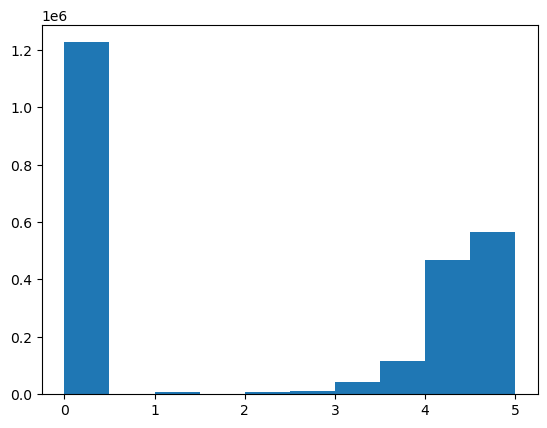

In [88]:
plt.hist(df.stars)

In [89]:
#Ratings of 5 are most common, followed by ratings of 4